# 08 - Market Evaluation of the Saved Models

This notebook evaluates the saved ML and double Poisson model outputs against the pre-match market benchmark prepared in notebook `07`.
It is intentionally designed as a read-only evaluation layer: the notebook does not retrain any models and only works with the saved prediction artifacts.

## 1. Methodological Goal

The goal of this section is to compare model performance with the betting market from several complementary perspectives.

We focus on four questions:
1. How accurate are the saved models relative to the market benchmark on the same matched sample?
2. How does performance evolve across Bundesliga matchdays?
3. When probability forecasts are available, are the models sharper or better calibrated than the market benchmark?
4. Under a simple and fully transparent value-bet rule, where do the model probabilities differ from market-implied probabilities?

The notebook therefore separates plain predictive evaluation from a betting-style illustration. The betting-style part is only a supplementary perspective and should not be treated as the main scientific evaluation criterion.

## 2. Imports and Setup

We load the processed market benchmark, discover which model runs are already available on disk, and import shared helper functions that keep the evaluation logic consistent across all saved runs.

In [32]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, TABLES_DIR
from src.market_evaluation import (
    build_binary_blanket_bet_summary,
    build_classification_comparison,
    build_coverage_summary,
    build_matchday_accuracy_frame,
    build_probability_comparison,
    build_probability_gap_frame,
    build_value_bet_summary,
    discover_available_runs,
    load_market_benchmark,
    load_run_bundle,
    merge_predictions_with_market,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


## 3. Load the Market Benchmark and Saved Model Runs

The benchmark table comes from notebook `07`. The run registry is discovered dynamically, which means the notebook can already be executed while some modeling notebooks are still running.

If a new run appears later, such as the multiclass ML run from notebook `05`, rerunning this notebook will automatically incorporate it into the comparison.

In [33]:
market_df = load_market_benchmark()
run_registry = discover_available_runs()
available_runs = run_registry.loc[run_registry['has_predictions']].copy()

print('Market benchmark shape:', market_df.shape)
print('Available saved runs:', len(available_runs))
display(run_registry)

if available_runs.empty:
    raise FileNotFoundError(
        'No saved model predictions were found under data/processed/model_runs/. '
        'Run notebooks 05, 05b, 06, or 06b first.'
    )


Market benchmark shape: (882, 279)
Available saved runs: 5


,run_key,display_name,task_group,target_col,run_dir_exists,has_predictions,has_results,best_model_name,trained_through_matchday,trained_through_date,trained_through_season_id
0,ml_multiclass,ML multiclass,multiclass,target_1x2,True,True,True,knn,30,2026-04-19 17:30:00,2025
1,ml_binary,ML binary,binary,home_win,True,True,True,naive_bayes,30,2026-04-19 17:30:00,2025
2,ml_betting_binary,ML betting binary,binary,home_win,True,True,False,logistic_regression,30,2026-04-19 17:30:00,2025
3,double_poisson_multiclass,Double Poisson multiclass,multiclass,target_1x2,True,True,True,double_poisson_alpha_0_1,30,2026-04-19 17:30:00,2025
4,double_poisson_binary,Double Poisson binary,binary,home_win,True,True,True,double_poisson_alpha_0_1,30,2026-04-19 17:30:00,2025


## 4. Benchmark Transparency and Coverage

Before comparing the models with the market, it is useful to summarize the market dataset itself.
This includes the seasonal coverage, the odds source, and the prevalence of the benchmark probability columns that will later be used for the comparisons.

In [34]:
benchmark_overview = pd.DataFrame(
    {
        'metric': [
            'Rows in market benchmark',
            'Distinct seasons',
            'Distinct teams',
            'Matches with benchmark 1X2 probabilities',
            'Matches with derived away-not-lose probabilities',
        ],
        'value': [
            len(market_df),
            market_df['season_id'].nunique(),
            pd.unique(pd.concat([market_df['home_team'], market_df['away_team']], ignore_index=True)).size,
            market_df['benchmark_home_prob'].notna().sum(),
            market_df['benchmark_away_not_lose_prob'].notna().sum(),
        ],
    }
)

source_summary = (
    market_df.groupby(['source_name', 'benchmark_stage', 'benchmark_odds_source'], dropna=False)
    .size()
    .reset_index(name='n_matches')
    .sort_values('n_matches', ascending=False)
)

display(benchmark_overview)
display(source_summary.head(10))
display(
    market_df[
        [
            'date',
            'season_id',
            'home_team',
            'away_team',
            'benchmark_odds_source',
            'benchmark_home_odds',
            'benchmark_draw_odds',
            'benchmark_away_odds',
            'benchmark_home_prob',
            'benchmark_draw_prob',
            'benchmark_away_prob',
            'benchmark_away_not_lose_prob',
        ]
    ].head()
)


,metric,value
0,Rows in market benchmark,882
1,Distinct seasons,3
2,Distinct teams,21
3,Matches with benchmark 1X2 probabilities,783
4,Matches with derived away-not-lose probabilities,783


,source_name,benchmark_stage,benchmark_odds_source,n_matches
0,Football-Data.co.uk,closing,market_average_close,783
1,NaN,NaN,NaN,99


,date,season_id,home_team,away_team,benchmark_odds_source,benchmark_home_odds,benchmark_draw_odds,benchmark_away_odds,benchmark_home_prob,benchmark_draw_prob,benchmark_away_prob,benchmark_away_not_lose_prob
0,2023-08-18 18:30:00,2023,Werder Bremen,Bayern Munich,market_average_close,8.69,6.05,1.31,0.110254,0.158365,0.731381,0.889746
1,2023-08-19 13:30:00,2023,Bayer Leverkusen,RasenBallsport Leipzig,market_average_close,2.44,3.60,2.81,0.392757,0.266202,0.341041,0.607243
2,2023-08-19 13:30:00,2023,Wolfsburg,FC Heidenheim,market_average_close,1.64,4.28,5.03,0.585062,0.224183,0.190756,0.414938
3,2023-08-19 13:30:00,2023,Hoffenheim,Freiburg,market_average_close,2.20,3.68,3.15,0.435495,0.260350,0.304155,0.564505
4,2023-08-19 13:30:00,2023,Augsburg,Borussia M.Gladbach,market_average_close,2.79,3.67,2.42,0.343276,0.260964,0.395760,0.656724


## 5. Load the Saved Best-Model Predictions

For each available run, we load the saved best-model predictions, merge them with the market benchmark by `game_id`, and construct a unified evaluation bundle.

The merge is intentionally evaluated and reported, because the market comparison is only valid on the set of matches that can be linked consistently between the model outputs and the odds benchmark.

In [35]:
loaded_runs = {}
merged_runs = {}

coverage_rows = []
classification_rows = []
matchday_frames = []
probability_rows = []
probability_gap_frames = []
betting_rows = []

threshold_grid = [0.025, 0.05, 0.075]

for run_key in available_runs['run_key']:
    bundle = load_run_bundle(run_key)
    if bundle is None:
        continue

    merged = merge_predictions_with_market(
        bundle['predictions'],
        market_df,
        task_group=bundle['spec']['task_group'],
    )

    loaded_runs[run_key] = bundle
    merged_runs[run_key] = merged

    coverage_rows.append(build_coverage_summary(bundle, merged))
    classification_rows.append(build_classification_comparison(merged, run_key))

    matchday_frame = build_matchday_accuracy_frame(merged, run_key)
    if not matchday_frame.empty:
        matchday_frames.append(matchday_frame)

    probability_rows.extend(build_probability_comparison(merged, run_key))

    probability_gap_frame = build_probability_gap_frame(merged, run_key)
    if not probability_gap_frame.empty:
        probability_gap_frames.append(probability_gap_frame)

    betting_rows.extend(build_binary_blanket_bet_summary(merged, run_key))

    for edge_threshold in threshold_grid:
        betting_rows.extend(
            build_value_bet_summary(
                merged,
                run_key,
                edge_threshold=edge_threshold,
            )
        )

coverage_summary = pd.DataFrame(coverage_rows).sort_values(['task_group', 'display_name'])
classification_summary = pd.DataFrame(classification_rows).sort_values(['task_group', 'display_name'])
matchday_accuracy = pd.concat(matchday_frames, ignore_index=True) if matchday_frames else pd.DataFrame()
probability_summary = pd.DataFrame(probability_rows)
probability_gaps = pd.concat(probability_gap_frames, ignore_index=True) if probability_gap_frames else pd.DataFrame()
betting_summary = pd.DataFrame(betting_rows)
blanket_betting_summary = betting_summary.loc[betting_summary['strategy_type'] == 'blanket_all'].copy() if not betting_summary.empty else pd.DataFrame()
value_betting_summary = betting_summary.loc[betting_summary['strategy_type'] == 'value_edge'].copy() if not betting_summary.empty else pd.DataFrame()

display(coverage_summary)


,run_key,display_name,task_group,best_model_name,trained_through_matchday,n_predictions,n_merged_matches,merge_coverage
4,double_poisson_binary,Double Poisson binary,binary,double_poisson_alpha_0_1,34,270,270,1.0
2,ml_betting_binary,ML betting binary,binary,logistic_regression,30,270,270,1.0
1,ml_binary,ML binary,binary,naive_bayes,34,270,270,1.0
3,double_poisson_multiclass,Double Poisson multiclass,multiclass,double_poisson_alpha_0_1,34,270,270,1.0
0,ml_multiclass,ML multiclass,multiclass,knn,34,270,270,1.0


## 6. Classification Performance Relative to the Market

The table below compares each saved model with the market benchmark on exactly the same matched sample.
This is important because the market merge coverage may differ slightly across runs.

The market benchmark uses the highest implied probability as its predicted outcome.
The reported deltas therefore answer a simple question: on the same set of matches, did the saved model outperform the market benchmark as a classifier?

,run_key,display_name,task_group,n_matches,model_accuracy,market_accuracy,accuracy_delta_model_minus_market,model_macro_f1,market_macro_f1,model_weighted_f1,market_weighted_f1
1,ml_binary,ML binary,binary,270,0.700000,0.720833,-0.020833,0.688900,0.701553,0.695865,0.710403
4,double_poisson_binary,Double Poisson binary,binary,270,0.696296,0.720833,-0.024537,0.656403,0.701553,0.670279,0.710403
2,ml_betting_binary,ML betting binary,binary,270,0.688889,0.720833,-0.031944,0.658947,0.701553,0.670924,0.710403
3,double_poisson_multiclass,Double Poisson multiclass,multiclass,270,0.555556,0.558333,-0.002778,0.403330,0.410961,0.467522,0.473259
0,ml_multiclass,ML multiclass,multiclass,270,0.514815,0.558333,-0.043519,0.457888,0.410961,0.493053,0.473259


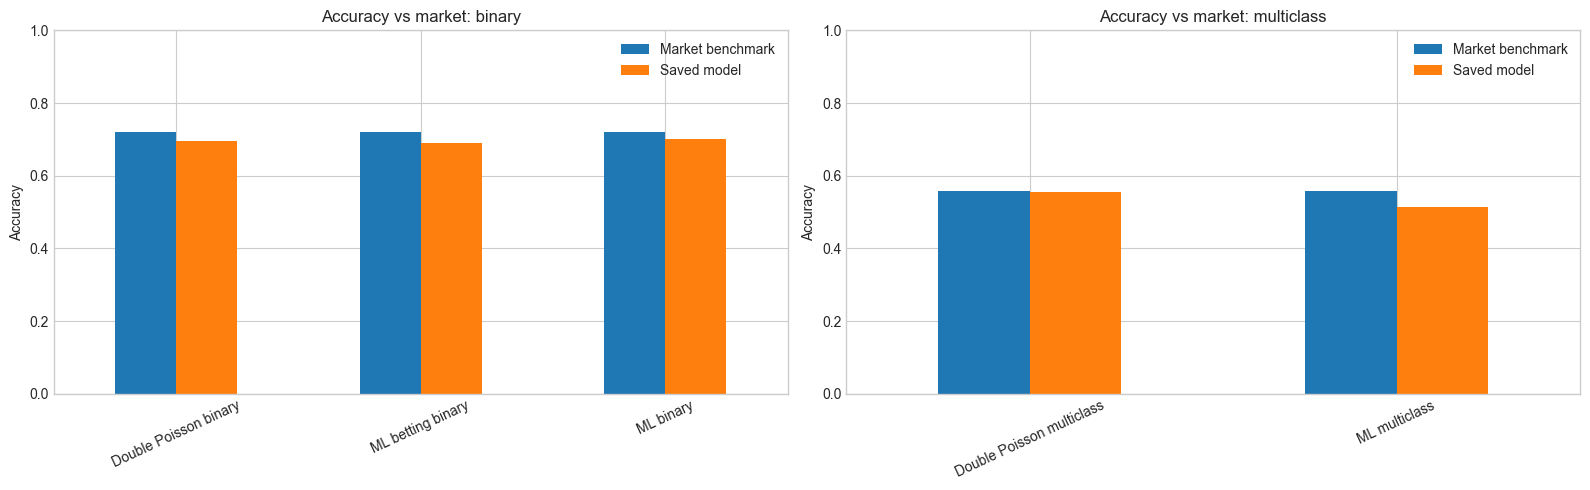

In [36]:
display(
    classification_summary.sort_values(
        ['task_group', 'model_accuracy'],
        ascending=[True, False],
    )
)

if not classification_summary.empty:
    plot_df = classification_summary.melt(
        id_vars=['run_key', 'display_name', 'task_group'],
        value_vars=['model_accuracy', 'market_accuracy'],
        var_name='metric_source',
        value_name='accuracy',
    )
    plot_df['metric_source'] = plot_df['metric_source'].map(
        {
            'model_accuracy': 'Saved model',
            'market_accuracy': 'Market benchmark',
        }
    )

    task_groups = list(plot_df['task_group'].dropna().unique())
    fig, axes = plt.subplots(1, len(task_groups), figsize=(8 * max(len(task_groups), 1), 5), squeeze=False)

    for ax, task_group in zip(axes[0], task_groups):
        subset = plot_df.loc[plot_df['task_group'] == task_group].copy()
        pivot = subset.pivot(index='display_name', columns='metric_source', values='accuracy')
        pivot.plot(kind='bar', ax=ax, rot=25)
        ax.set_title(f'Accuracy vs market: {task_group}')
        ax.set_xlabel('')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.legend(title='')

    plt.tight_layout()
    accuracy_vs_market_fig = fig
    plt.show()


## 7. Matchday-Level Accuracy Dynamics

Aggregate accuracy can hide whether a model is stable across the season or whether its edge appears only in a few rounds.
The next chart therefore traces the model accuracy and the market benchmark accuracy matchday by matchday.

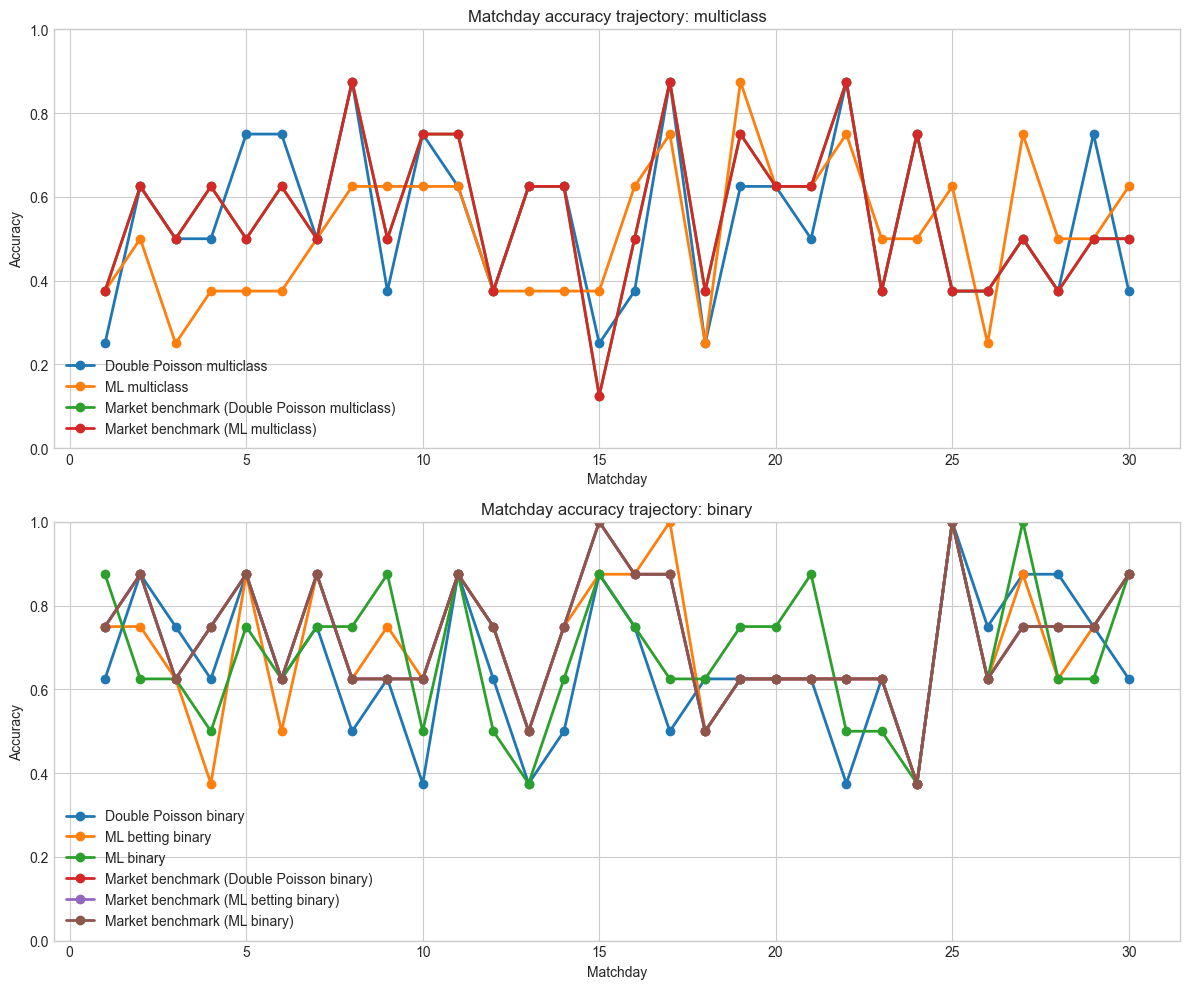

In [37]:
if matchday_accuracy.empty:
    print('No matchday accuracy data are available yet.')
else:
    matchday_accuracy['matchday'] = pd.to_numeric(matchday_accuracy['matchday'], errors='coerce')
    task_groups = list(matchday_accuracy['task_group'].dropna().unique())
    fig, axes = plt.subplots(len(task_groups), 1, figsize=(12, 5 * max(len(task_groups), 1)), squeeze=False)

    for ax, task_group in zip(axes[:, 0], task_groups):
        subset = matchday_accuracy.loc[matchday_accuracy['task_group'] == task_group].copy()
        for competitor, competitor_df in subset.groupby('competitor'):
            competitor_df = competitor_df.sort_values('matchday')
            ax.plot(
                competitor_df['matchday'],
                competitor_df['accuracy'],
                marker='o',
                linewidth=2,
                label=competitor,
            )
        ax.set_title(f'Matchday accuracy trajectory: {task_group}')
        ax.set_xlabel('Matchday')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.legend(loc='best')

    plt.tight_layout()
    matchday_accuracy_fig = fig
    plt.show()


## 8. Probability Quality and Model-Market Gaps

This section is only available for runs that save explicit probabilities.
At the moment this applies to the double Poisson models and the market-aware binary pricing run from notebook `05c`.

The probability comparison serves two roles:
- it evaluates whether the probability forecasts are sharper than the market benchmark, and
- it identifies systematic model-market disagreements that can later be interpreted in methodological terms.

For the current ML runs, the saved artifacts contain class predictions but not probability vectors, so the notebook transparently skips the probability-specific metrics for those runs.

,run_key,display_name,task_group,probability_view,competitor,n_matches,log_loss,brier_score,multiclass_brier
8,double_poisson_binary,Double Poisson binary,binary,Away not lose,Double Poisson binary,270,0.618411,0.213976,NaN
2,ml_betting_binary,ML betting binary,binary,Away not lose,ML betting binary,270,0.601707,0.206982,NaN
3,ml_betting_binary,ML betting binary,binary,Away not lose,Market benchmark,240,0.587641,0.201016,NaN
9,double_poisson_binary,Double Poisson binary,binary,Away not lose,Market benchmark,240,0.587641,0.201016,NaN
6,double_poisson_binary,Double Poisson binary,binary,Home win,Double Poisson binary,270,0.618411,0.213976,NaN
0,ml_betting_binary,ML betting binary,binary,Home win,ML betting binary,270,0.601707,0.206982,NaN
1,ml_betting_binary,ML betting binary,binary,Home win,Market benchmark,240,0.587641,0.201016,NaN
7,double_poisson_binary,Double Poisson binary,binary,Home win,Market benchmark,240,0.587641,0.201016,NaN
4,double_poisson_multiclass,Double Poisson multiclass,multiclass,1X2,Double Poisson multiclass,270,0.995859,NaN,0.591226
5,double_poisson_multiclass,Double Poisson multiclass,multiclass,1X2,Market benchmark,240,0.959747,NaN,0.567739


,display_name,n_matches,mean_abs_home_win_gap,mean_home_win_gap,mean_abs_away_not_lose_gap,mean_away_not_lose_gap,mean_abs_home_prob_gap,mean_home_prob_gap,mean_abs_draw_prob_gap,mean_draw_prob_gap,mean_abs_away_prob_gap,mean_away_prob_gap
0,Double Poisson binary,270,0.070678,-0.013605,0.070678,0.013605,NaN,NaN,NaN,NaN,NaN,NaN
1,Double Poisson multiclass,270,NaN,NaN,NaN,NaN,0.070678,-0.013605,0.028693,-0.010393,0.067632,0.023998
2,ML betting binary,270,0.045853,-0.025269,0.045853,0.025269,NaN,NaN,NaN,NaN,NaN,NaN


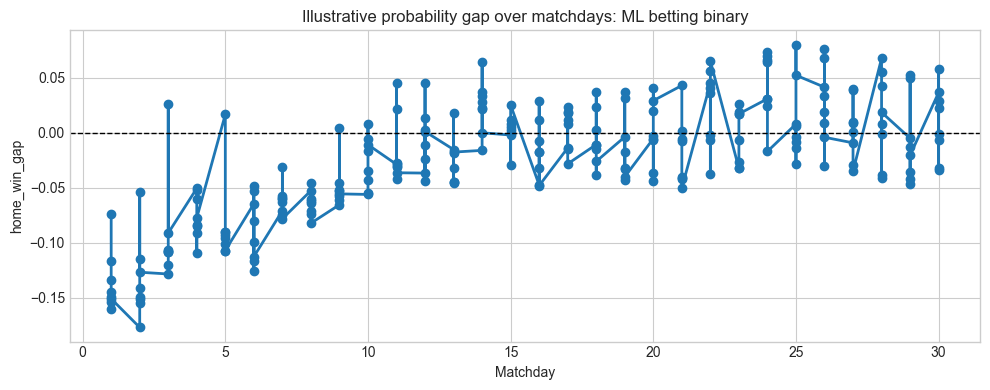

In [38]:
if probability_summary.empty:
    print('No probability-based metrics are available for the currently saved runs.')
else:
    display(
        probability_summary.sort_values(
            ['task_group', 'probability_view', 'competitor', 'log_loss'],
            ascending=[True, True, True, True],
        )
    )

gap_summary_rows = []
if not probability_gaps.empty:
    for display_name, group in probability_gaps.groupby('display_name'):
        row = {'display_name': display_name, 'n_matches': len(group)}
        for column in group.columns:
            if column.endswith('_gap'):
                row[f'mean_abs_{column}'] = group[column].abs().mean()
                row[f'mean_{column}'] = group[column].mean()
        gap_summary_rows.append(row)

gap_summary = pd.DataFrame(gap_summary_rows)
if not gap_summary.empty:
    display(gap_summary.sort_values('display_name'))

home_gap_cols = [col for col in probability_gaps.columns if 'home' in col and col.endswith('_gap')]
if home_gap_cols:
    first_home_gap_col = home_gap_cols[0]
    example_display_name = probability_gaps['display_name'].iloc[0]
    example_gap = probability_gaps.loc[
        probability_gaps['display_name'] == example_display_name,
        ['matchday', first_home_gap_col],
    ].dropna()
    if not example_gap.empty:
        example_gap = example_gap.sort_values('matchday')
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(example_gap['matchday'], example_gap[first_home_gap_col], marker='o', linewidth=2)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Illustrative probability gap over matchdays: {example_display_name}')
        ax.set_xlabel('Matchday')
        ax.set_ylabel(first_home_gap_col)
        plt.tight_layout()
        probability_gap_fig = fig
        plt.show()


## 9. Focused Comparison: Standard Binary ML vs Betting-Oriented Binary ML

This section compares the standard binary ML workflow from notebook `05b` with the market-aware betting workflow from notebook `05c`.
The purpose is to isolate whether the betting-oriented redesign improves the project specifically on the binary task.

When both runs are available, the comparison looks at three layers:
- classification performance,
- probability quality,
- and betting-style ROI summaries.


Classification comparison


,run_key,display_name,task_group,n_matches,model_accuracy,market_accuracy,accuracy_delta_model_minus_market,model_macro_f1,market_macro_f1,model_weighted_f1,market_weighted_f1
2,ml_betting_binary,ML betting binary,binary,270,0.688889,0.720833,-0.031944,0.658947,0.701553,0.670924,0.710403
1,ml_binary,ML binary,binary,270,0.700000,0.720833,-0.020833,0.688900,0.701553,0.695865,0.710403


Probability comparison


,run_key,display_name,task_group,probability_view,competitor,n_matches,log_loss,brier_score,multiclass_brier
2,ml_betting_binary,ML betting binary,binary,Away not lose,ML betting binary,270,0.601707,0.206982,NaN
3,ml_betting_binary,ML betting binary,binary,Away not lose,Market benchmark,240,0.587641,0.201016,NaN
0,ml_betting_binary,ML betting binary,binary,Home win,ML betting binary,270,0.601707,0.206982,NaN
1,ml_betting_binary,ML betting binary,binary,Home win,Market benchmark,240,0.587641,0.201016,NaN


Betting comparison


,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
3,ml_betting_binary,ML betting binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
2,ml_betting_binary,ML betting binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000
5,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.025,117,0.683761,0.038067,0.069455,1.650855,4.453816
7,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.050,68,0.588235,-0.015577,0.092816,1.794793,-1.059230
9,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.075,41,0.585366,0.001132,0.114731,1.791556,0.046417
4,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.025,43,0.697674,0.056977,0.046146,1.520233,2.450000
6,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.050,16,0.562500,-0.201875,0.063905,1.433125,-3.230000
8,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.075,2,0.500000,-0.335000,0.078207,1.370000,-0.670000
1,ml_binary,ML binary,Bet every away not lose,blanket_all,0.000,240,0.558333,-0.025701,0.000000,2.059695,-6.168193
0,ml_binary,ML binary,Bet every home win,blanket_all,0.000,240,0.441667,-0.132625,0.000000,2.592667,-31.830000


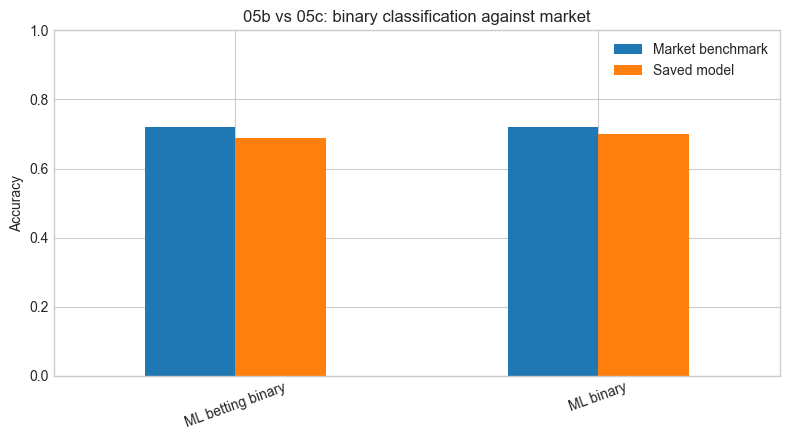

In [39]:
binary_focus_run_keys = ['ml_binary', 'ml_betting_binary']

binary_focus_classification = classification_summary.loc[
    classification_summary['run_key'].isin(binary_focus_run_keys)
].copy()

binary_focus_probability = probability_summary.loc[
    probability_summary['run_key'].isin(binary_focus_run_keys)
].copy() if not probability_summary.empty else pd.DataFrame()

binary_focus_betting = betting_summary.loc[
    betting_summary['run_key'].isin(binary_focus_run_keys)
].copy() if not betting_summary.empty else pd.DataFrame()

if binary_focus_classification.empty:
    print('The binary comparison section will populate once ml_binary and/or ml_betting_binary runs are available.')
else:
    print('Classification comparison')
    display(binary_focus_classification.sort_values('display_name'))

    if not binary_focus_probability.empty:
        print('Probability comparison')
        display(binary_focus_probability.sort_values(['display_name', 'probability_view', 'competitor']))
    else:
        print('Probability comparison is not available for all binary runs yet.')

    if not binary_focus_betting.empty:
        print('Betting comparison')
        display(binary_focus_betting.sort_values(['display_name', 'strategy_type', 'bet_view', 'edge_threshold']))

    if len(binary_focus_classification) >= 2:
        focus_plot_df = binary_focus_classification.melt(
            id_vars=['display_name'],
            value_vars=['model_accuracy', 'market_accuracy'],
            var_name='metric_source',
            value_name='accuracy',
        )
        focus_plot_df['metric_source'] = focus_plot_df['metric_source'].map(
            {
                'model_accuracy': 'Saved model',
                'market_accuracy': 'Market benchmark',
            }
        )

        fig, ax = plt.subplots(figsize=(8, 4.5))
        focus_pivot = focus_plot_df.pivot(index='display_name', columns='metric_source', values='accuracy')
        focus_pivot.plot(kind='bar', ax=ax, rot=20)
        ax.set_title('05b vs 05c: binary classification against market')
        ax.set_xlabel('')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.legend(title='')
        plt.tight_layout()
        binary_focus_fig = fig
        plt.show()


## 10. Betting-Style Illustration

This section applies a simple value-bet rule based on the difference between model probability and market-implied probability.

The procedure is intentionally transparent:
- a bet is triggered only when the model probability exceeds the market probability by at least a fixed edge threshold,
- the notebook also reports blanket binary strategies that simply bet every `home_win` or every `away_not_lose` outcome,
- a flat stake of one unit is assumed,
- the resulting hit rate and ROI are descriptive only.

Two methodological caveats are important:
1. This is not the primary evaluation criterion of the thesis; it is only an auxiliary interpretation layer.
2. For the binary `away_not_lose` event, the project currently derives fair odds from normalized `1X2` benchmark probabilities rather than from directly observed bookmaker double-chance quotes.


Blanket binary strategies


,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
14,double_poisson_binary,Double Poisson binary,Bet every away not lose,blanket_all,0.0,240,0.558333,-0.025701,0.0,2.059695,-6.168193
13,double_poisson_binary,Double Poisson binary,Bet every home win,blanket_all,0.0,240,0.441667,-0.132625,0.0,2.592667,-31.830000
3,ml_betting_binary,ML betting binary,Bet every away not lose,blanket_all,0.0,240,0.558333,-0.025701,0.0,2.059695,-6.168193
2,ml_betting_binary,ML betting binary,Bet every home win,blanket_all,0.0,240,0.441667,-0.132625,0.0,2.592667,-31.830000
1,ml_binary,ML binary,Bet every away not lose,blanket_all,0.0,240,0.558333,-0.025701,0.0,2.059695,-6.168193
0,ml_binary,ML binary,Bet every home win,blanket_all,0.0,240,0.441667,-0.132625,0.0,2.592667,-31.830000


Value-based strategies


,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
10,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.025,216,0.203704,-0.285324,0.079232,4.688519,-61.630000
11,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.050,161,0.180124,-0.275466,0.092836,5.302422,-44.350000
12,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.075,99,0.141414,-0.320404,0.112535,6.310909,-31.720000
5,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.025,117,0.683761,0.038067,0.069455,1.650855,4.453816
16,double_poisson_binary,Double Poisson binary,Away not lose value bets,value_edge,0.025,101,0.356436,-0.150919,0.096361,2.734544,-15.242780
7,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.050,68,0.588235,-0.015577,0.092816,1.794793,-1.059230
18,double_poisson_binary,Double Poisson binary,Away not lose value bets,value_edge,0.050,76,0.328947,-0.147058,0.115879,2.996590,-11.176380
9,ml_betting_binary,ML betting binary,Away not lose value bets,value_edge,0.075,41,0.585366,0.001132,0.114731,1.791556,0.046417
20,double_poisson_binary,Double Poisson binary,Away not lose value bets,value_edge,0.075,55,0.309091,-0.110367,0.135243,3.324079,-6.070185
4,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.025,43,0.697674,0.056977,0.046146,1.520233,2.450000


,run_key,display_name,bet_view,strategy_type,edge_threshold,n_bets,hit_rate,roi,avg_edge,avg_offered_odds,total_profit
19,double_poisson_binary,Double Poisson binary,Home win value bets,value_edge,0.075,35,0.142857,-0.527143,0.116997,5.330857,-18.450000
17,double_poisson_binary,Double Poisson binary,Home win value bets,value_edge,0.050,59,0.203390,-0.406271,0.093909,4.273390,-23.970000
15,double_poisson_binary,Double Poisson binary,Home win value bets,value_edge,0.025,82,0.231707,-0.393537,0.079029,3.784756,-32.270000
8,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.075,2,0.500000,-0.335000,0.078207,1.370000,-0.670000
12,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.075,99,0.141414,-0.320404,0.112535,6.310909,-31.720000
10,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.025,216,0.203704,-0.285324,0.079232,4.688519,-61.630000
11,double_poisson_multiclass,Double Poisson multiclass,1X2 value bets,value_edge,0.050,161,0.180124,-0.275466,0.092836,5.302422,-44.350000
6,ml_betting_binary,ML betting binary,Home win value bets,value_edge,0.050,16,0.562500,-0.201875,0.063905,1.433125,-3.230000
16,double_poisson_binary,Double Poisson binary,Away not lose value bets,value_edge,0.025,101,0.356436,-0.150919,0.096361,2.734544,-15.242780
18,double_poisson_binary,Double Poisson binary,Away not lose value bets,value_edge,0.050,76,0.328947,-0.147058,0.115879,2.996590,-11.176380


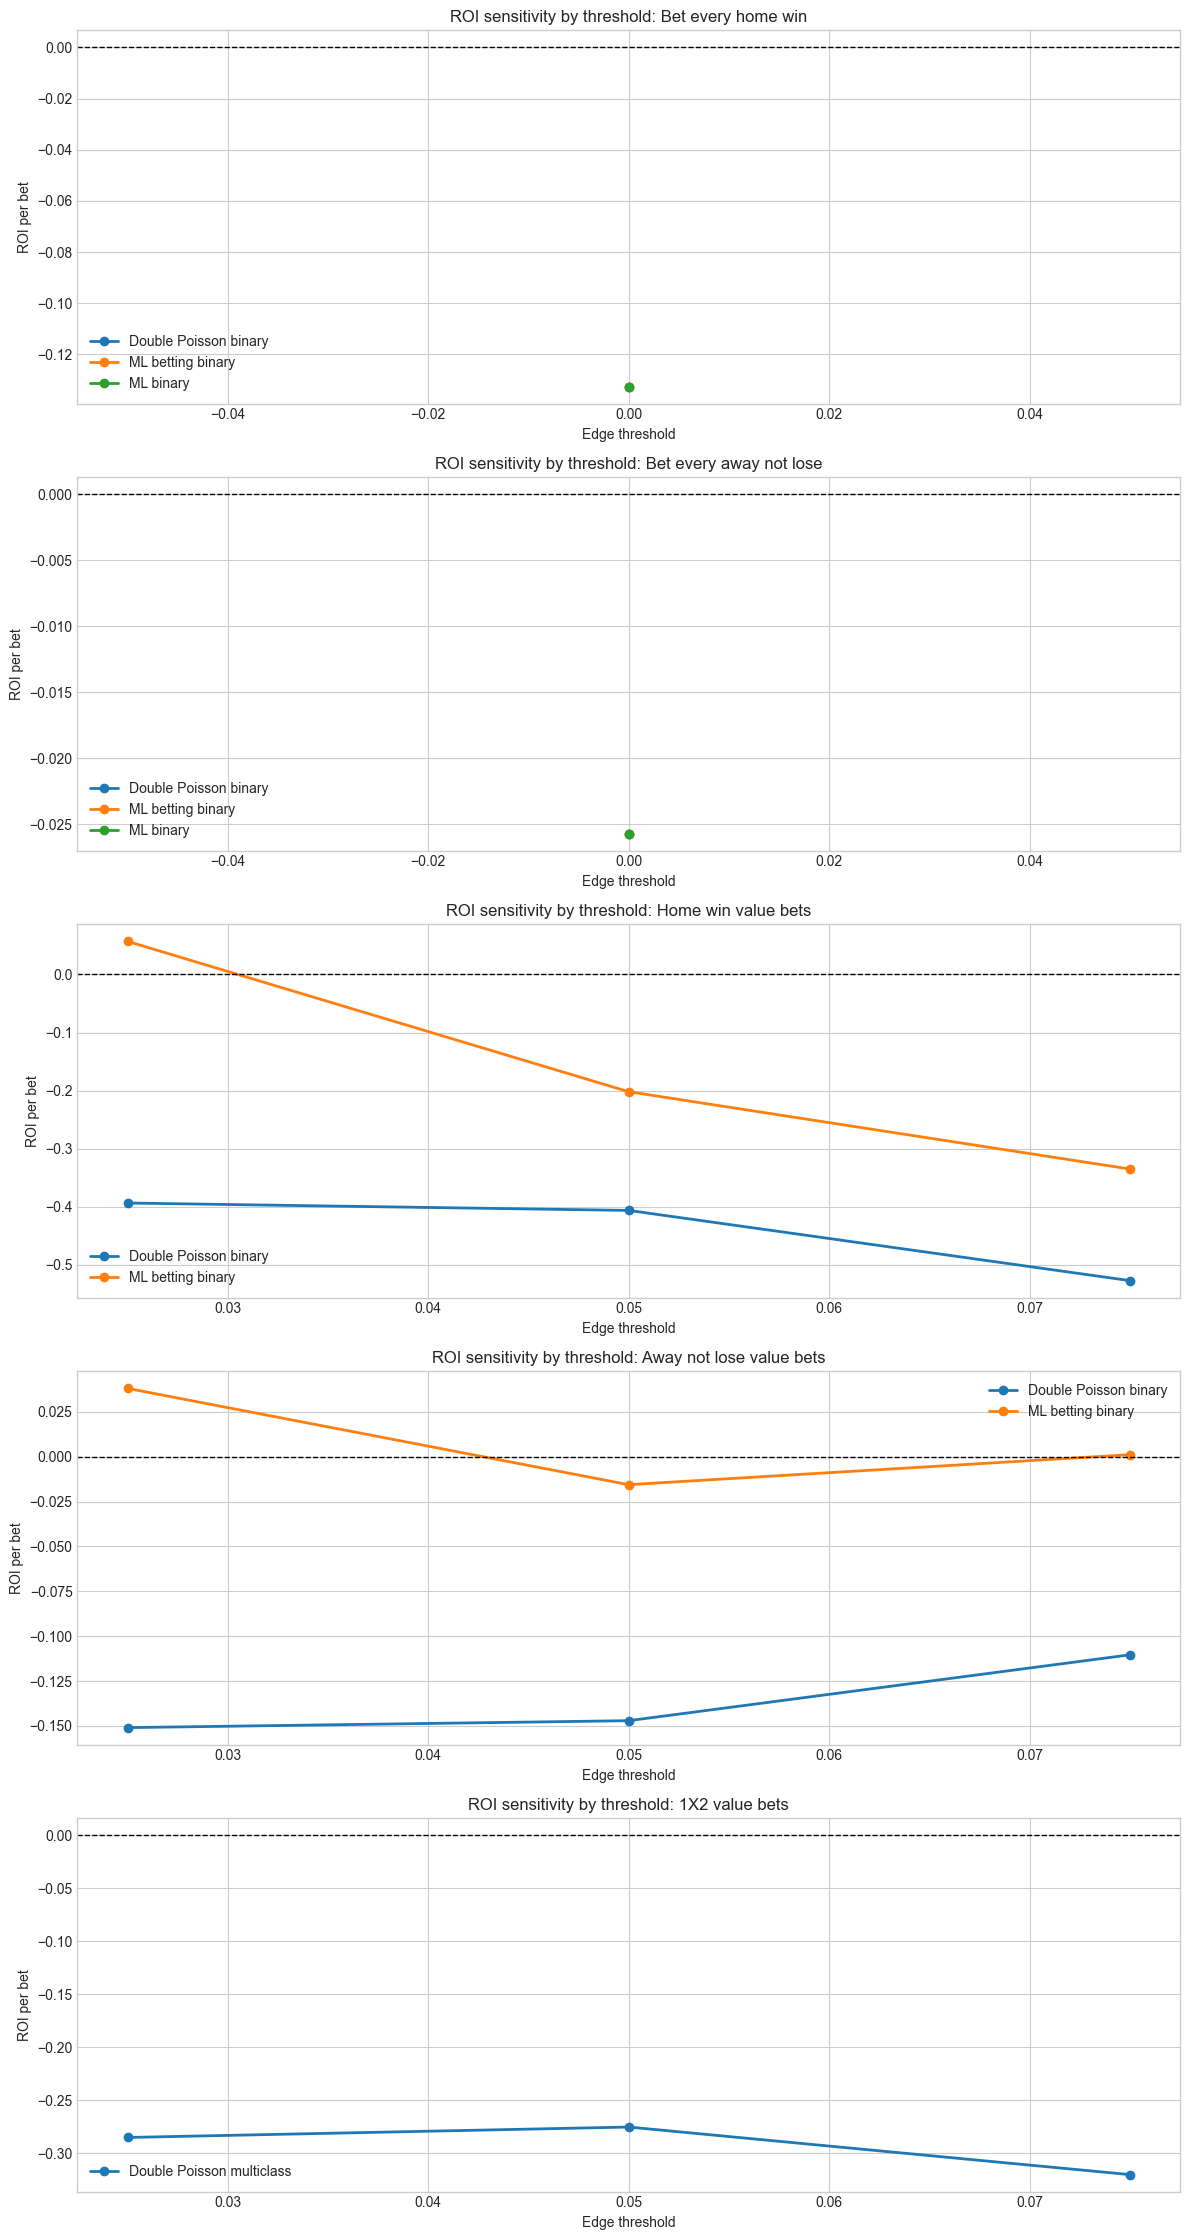

In [ ]:
if betting_summary.empty:
    print('No betting-style summary could be computed for the currently saved runs.')
else:
    if not blanket_betting_summary.empty:
        print('Blanket binary strategies')
        display(blanket_betting_summary.sort_values(['display_name', 'bet_view']))

    if not value_betting_summary.empty:
        print('Value-based strategies')
        display(
            value_betting_summary.sort_values(
                ['bet_view', 'edge_threshold', 'roi'],
                ascending=[True, True, False],
            )
        )

    display(
        betting_summary.sort_values(
            ['roi','strategy_type', 'bet_view', 'edge_threshold', ],
            ascending=[True, True, True, False],
        )
    )

## 11. Save the Evaluation Outputs

To keep the later reporting pipeline lightweight, the key comparison tables are saved to disk.
This allows notebook `09` to build a report directly from the processed evaluation outputs without repeating the merge and comparison work.


In [41]:
processed_output_dir = PROCESSED_DATA_DIR / 'market_evaluation'
tables_output_dir = TABLES_DIR / 'market_evaluation'
figures_output_dir = FIGURES_DIR / 'market_evaluation'

processed_output_dir.mkdir(parents=True, exist_ok=True)
tables_output_dir.mkdir(parents=True, exist_ok=True)
figures_output_dir.mkdir(parents=True, exist_ok=True)

coverage_summary.to_csv(processed_output_dir / 'coverage_summary.csv', index=False)
classification_summary.to_csv(processed_output_dir / 'classification_summary.csv', index=False)

if not matchday_accuracy.empty:
    matchday_accuracy.to_csv(processed_output_dir / 'matchday_accuracy.csv', index=False)
if not probability_summary.empty:
    probability_summary.to_csv(processed_output_dir / 'probability_summary.csv', index=False)
if not probability_gaps.empty:
    probability_gaps.to_csv(processed_output_dir / 'probability_gaps.csv', index=False)
if not gap_summary.empty:
    gap_summary.to_csv(processed_output_dir / 'probability_gap_summary.csv', index=False)
if not betting_summary.empty:
    betting_summary.to_csv(processed_output_dir / 'betting_summary.csv', index=False)
if not blanket_betting_summary.empty:
    blanket_betting_summary.to_csv(processed_output_dir / 'blanket_betting_summary.csv', index=False)
if not value_betting_summary.empty:
    value_betting_summary.to_csv(processed_output_dir / 'value_betting_summary.csv', index=False)
if 'binary_focus_classification' in globals() and not binary_focus_classification.empty:
    binary_focus_classification.to_csv(processed_output_dir / 'binary_focus_classification.csv', index=False)
if 'binary_focus_probability' in globals() and not binary_focus_probability.empty:
    binary_focus_probability.to_csv(processed_output_dir / 'binary_focus_probability.csv', index=False)
if 'binary_focus_betting' in globals() and not binary_focus_betting.empty:
    binary_focus_betting.to_csv(processed_output_dir / 'binary_focus_betting.csv', index=False)

coverage_summary.to_csv(tables_output_dir / 'coverage_summary.csv', index=False)
classification_summary.to_csv(tables_output_dir / 'classification_summary.csv', index=False)
if 'binary_focus_classification' in globals() and not binary_focus_classification.empty:
    binary_focus_classification.to_csv(tables_output_dir / 'binary_focus_classification.csv', index=False)

if 'accuracy_vs_market_fig' in globals():
    accuracy_vs_market_fig.savefig(figures_output_dir / 'accuracy_vs_market.png', dpi=150, bbox_inches='tight')
if 'matchday_accuracy_fig' in globals():
    matchday_accuracy_fig.savefig(figures_output_dir / 'matchday_accuracy.png', dpi=150, bbox_inches='tight')
if 'probability_gap_fig' in globals():
    probability_gap_fig.savefig(figures_output_dir / 'probability_gap_example.png', dpi=150, bbox_inches='tight')
if 'betting_roi_fig' in globals():
    betting_roi_fig.savefig(figures_output_dir / 'betting_roi.png', dpi=150, bbox_inches='tight')
if 'binary_focus_fig' in globals():
    binary_focus_fig.savefig(figures_output_dir / 'binary_focus_accuracy.png', dpi=150, bbox_inches='tight')

print('Saved processed outputs to:', processed_output_dir)
print('Saved tables to:', tables_output_dir)
print('Saved figures to:', figures_output_dir)


Saved processed outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\market_evaluation
Saved tables to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\tables\market_evaluation
Saved figures to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\figures\market_evaluation
